# Student Performance Predictor

**Problem Statement:** Predict a student's final marks using academic and personal factors.

This notebook generates a synthetic dataset, performs EDA, preprocesses data, trains multiple regression models, evaluates them, and saves the best model.

## Step 1: Import Libraries

In [5]:
# Print the active notebook kernel environment and install required libraries
import sys
print('Python executable:', sys.executable)
print('Python version:', sys.version)

%pip install pandas matplotlib seaborn scikit-learn

# Data science imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

sns.set(style='whitegrid')
%matplotlib inline

Python executable: C:\Users\kunch\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe
Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\kunch\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Step 2: Data Collection (Generate synthetic dataset)

In [6]:
# Set seed for reproducibility
np.random.seed(42)
n = 1000

# Generate features per rules
study_hours = np.round(np.random.uniform(1, 10, n), 2)
attendance = np.round(np.random.uniform(50, 100, n), 2)
previous_score = np.round(np.random.uniform(40, 100, n), 2)
assignment_score = np.round(np.random.uniform(40, 100, n), 2)
gender = np.random.choice(['Male', 'Female'], size=n)
parent_education = np.random.choice(['High School', 'Graduate', 'Post Graduate'], size=n, p=[0.4, 0.4, 0.2])

# Realistic formula for Final_Marks with noise and small biases
gender_bias = np.where(gender == 'Female', 0.5, 0.0)
parent_bonus_map = {'High School': -2.0, 'Graduate': 2.0, 'Post Graduate': 4.0}
parent_bonus = np.array([parent_bonus_map[p] for p in parent_education])

noise = np.random.normal(0, 5, n)  # standard deviation 5
final_marks = (0.4 * previous_score) + (0.25 * assignment_score) + (2.5 * study_hours) + (0.1 * attendance) + gender_bias + parent_bonus + noise
final_marks = np.clip(np.round(final_marks, 2), 0, 100)

# Create DataFrame
df = pd.DataFrame({
    'Study_Hours': study_hours,
    'Attendance': attendance,
    'Previous_Score': previous_score,
    'Assignment_Score': assignment_score,
    'Gender': gender,
    'Parent_Education': parent_education,
    'Final_Marks': final_marks
})

# Save to CSV as requested
df.to_csv('student_performance.csv', index=False)
print('Saved student_performance.csv with', len(df), 'rows')

Saved student_performance.csv with 1000 rows


Display first 10 rows and dataset info

In [7]:
df.head(10)

,Study_Hours,Attendance,Previous_Score,Assignment_Score,Gender,Parent_Education,Final_Marks
0,4.37,59.26,55.70,80.36,Female,Graduate,58.45
1,9.56,77.10,54.82,87.80,Male,Graduate,77.62
2,7.59,93.65,94.38,55.03,Female,High School,78.11
3,6.39,86.61,54.97,77.49,Male,High School,56.09
4,2.40,90.33,56.32,74.30,Male,Graduate,53.43
5,2.40,82.94,85.56,89.97,Male,High School,66.21
6,1.52,84.61,66.98,94.37,Female,Graduate,54.96
7,8.80,92.46,86.60,40.73,Male,High School,74.31
8,6.41,62.48,43.92,80.44,Female,Graduate,61.21
9,7.37,74.47,69.25,43.11,Male,Post Graduate,59.99


In [8]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.info()

Shape: (1000, 7)
Columns: ['Study_Hours', 'Attendance', 'Previous_Score', 'Assignment_Score', 'Gender', 'Parent_Education', 'Final_Marks']
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Study_Hours       1000 non-null   float64
 1   Attendance        1000 non-null   float64
 2   Previous_Score    1000 non-null   float64
 3   Assignment_Score  1000 non-null   float64
 4   Gender            1000 non-null   str    
 5   Parent_Education  1000 non-null   str    
 6   Final_Marks       1000 non-null   float64
dtypes: float64(5), str(2)
memory usage: 54.8 KB


## Step 3: Data Preprocessing

In [9]:
# Check missing values
df.isnull().sum()

Study_Hours         0
Attendance          0
Previous_Score      0
Assignment_Score    0
Gender              0
Parent_Education    0
Final_Marks         0
dtype: int64

No missing values expected because we generated the dataset. If there were, we'd fill or drop them.

In [10]:
# Check duplicates
dups = df.duplicated().sum()
print('Duplicate rows:', dups)
# Remove duplicates if any
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after dropping duplicates:', df.shape)

Duplicate rows: 0
Shape after dropping duplicates: (1000, 7)


### Encode Categorical Features

In [11]:
# Encode Gender using LabelEncoder and Parent_Education using OneHotEncoder (pd.get_dummies for simplicity)
le = LabelEncoder()
df['Gender_enc'] = le.fit_transform(df['Gender'])  # Female=0, Male=1 (depending on sorting)

# One-hot encode Parent_Education
df = pd.concat([df, pd.get_dummies(df['Parent_Education'], prefix='Parent')], axis=1)
df.drop(['Gender', 'Parent_Education'], axis=1, inplace=True)
df.head(3)

,Study_Hours,Attendance,Previous_Score,Assignment_Score,Final_Marks,Gender_enc,Parent_Graduate,Parent_High School,Parent_Post Graduate
0,4.37,59.26,55.70,80.36,58.45,0,True,False,False
1,9.56,77.10,54.82,87.80,77.62,1,True,False,False
2,7.59,93.65,94.38,55.03,78.11,0,False,True,False


### Feature Scaling (Optional) and Train-Test Split

In [12]:
# Define features and target
X = df.drop('Final_Marks', axis=1)
y = df['Final_Marks']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

# Scale numeric features for models that benefit from scaling (Linear Regression)
numeric_cols = ['Study_Hours', 'Attendance', 'Previous_Score', 'Assignment_Score']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Use scaled sets for linear regression and unscaled for tree-based models if desired
X_train_scaled.head(2)

Train shape: (800, 8) Test shape: (200, 8)


,Study_Hours,Attendance,Previous_Score,Assignment_Score,Gender_enc,Parent_Graduate,Parent_High School,Parent_Post Graduate
29,-1.533340,1.078137,0.507438,0.508619,0,False,True,False
535,1.534982,-1.345645,1.129602,-1.243389,0,False,True,False


## Step 4: Exploratory Data Analysis (EDA)

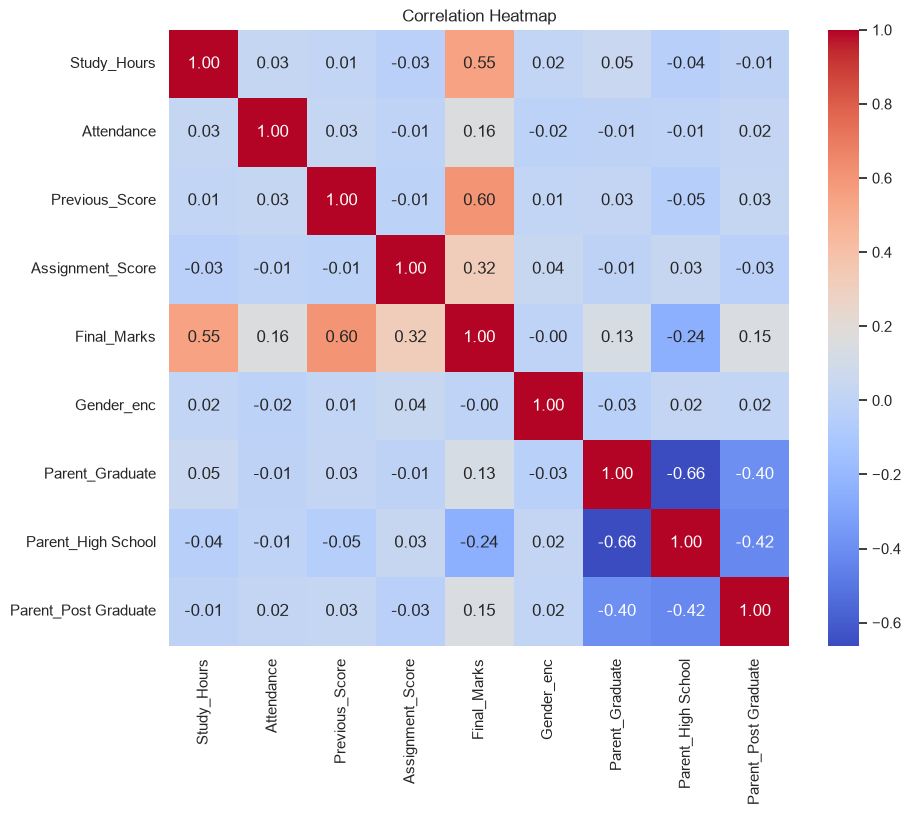

In [13]:
# Correlation heatmap
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

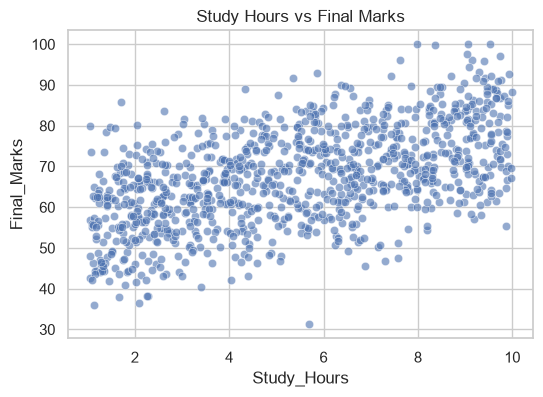

In [14]:
# Study Hours vs Final Marks
plt.figure(figsize=(6,4))
sns.scatterplot(x='Study_Hours', y='Final_Marks', data=df, alpha=0.6)
plt.title('Study Hours vs Final Marks')
plt.show()

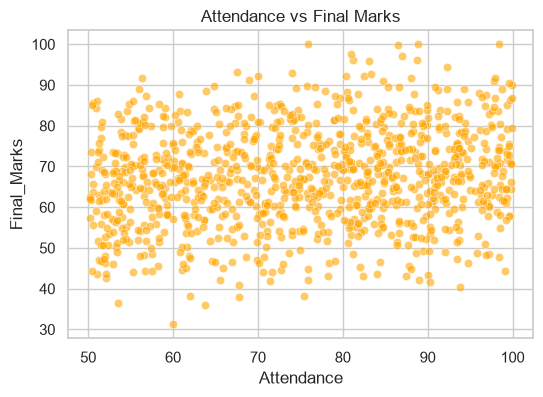

In [15]:
# Attendance vs Final Marks
plt.figure(figsize=(6,4))
sns.scatterplot(x='Attendance', y='Final_Marks', data=df, alpha=0.6, color='orange')
plt.title('Attendance vs Final Marks')
plt.show()

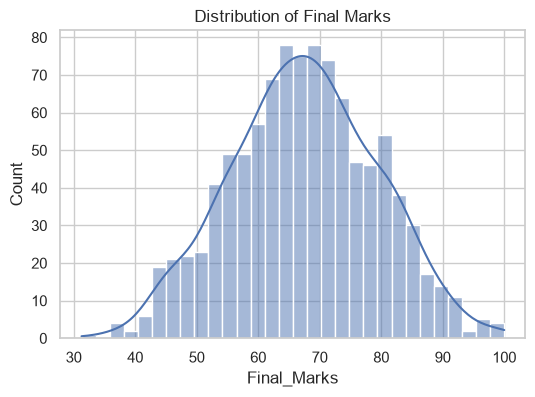

In [16]:
# Distribution of Final Marks
plt.figure(figsize=(6,4))
sns.histplot(df['Final_Marks'], bins=30, kde=True)
plt.title('Distribution of Final Marks')
plt.show()

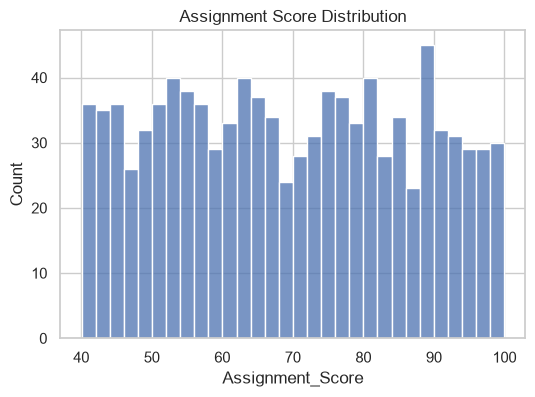

In [17]:
# Assignment Score Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Assignment_Score'], bins=30)
plt.title('Assignment Score Distribution')
plt.show()

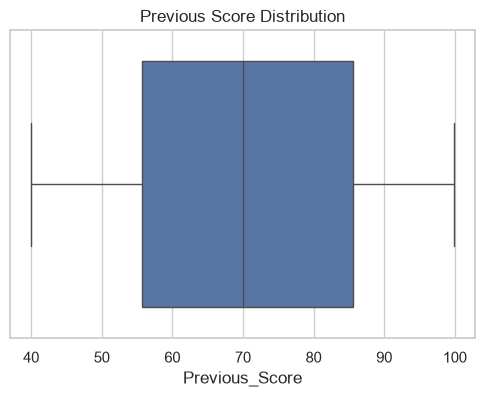

In [18]:
# Previous Score Analysis (boxplot)
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Previous_Score'])
plt.title('Previous Score Distribution')
plt.show()

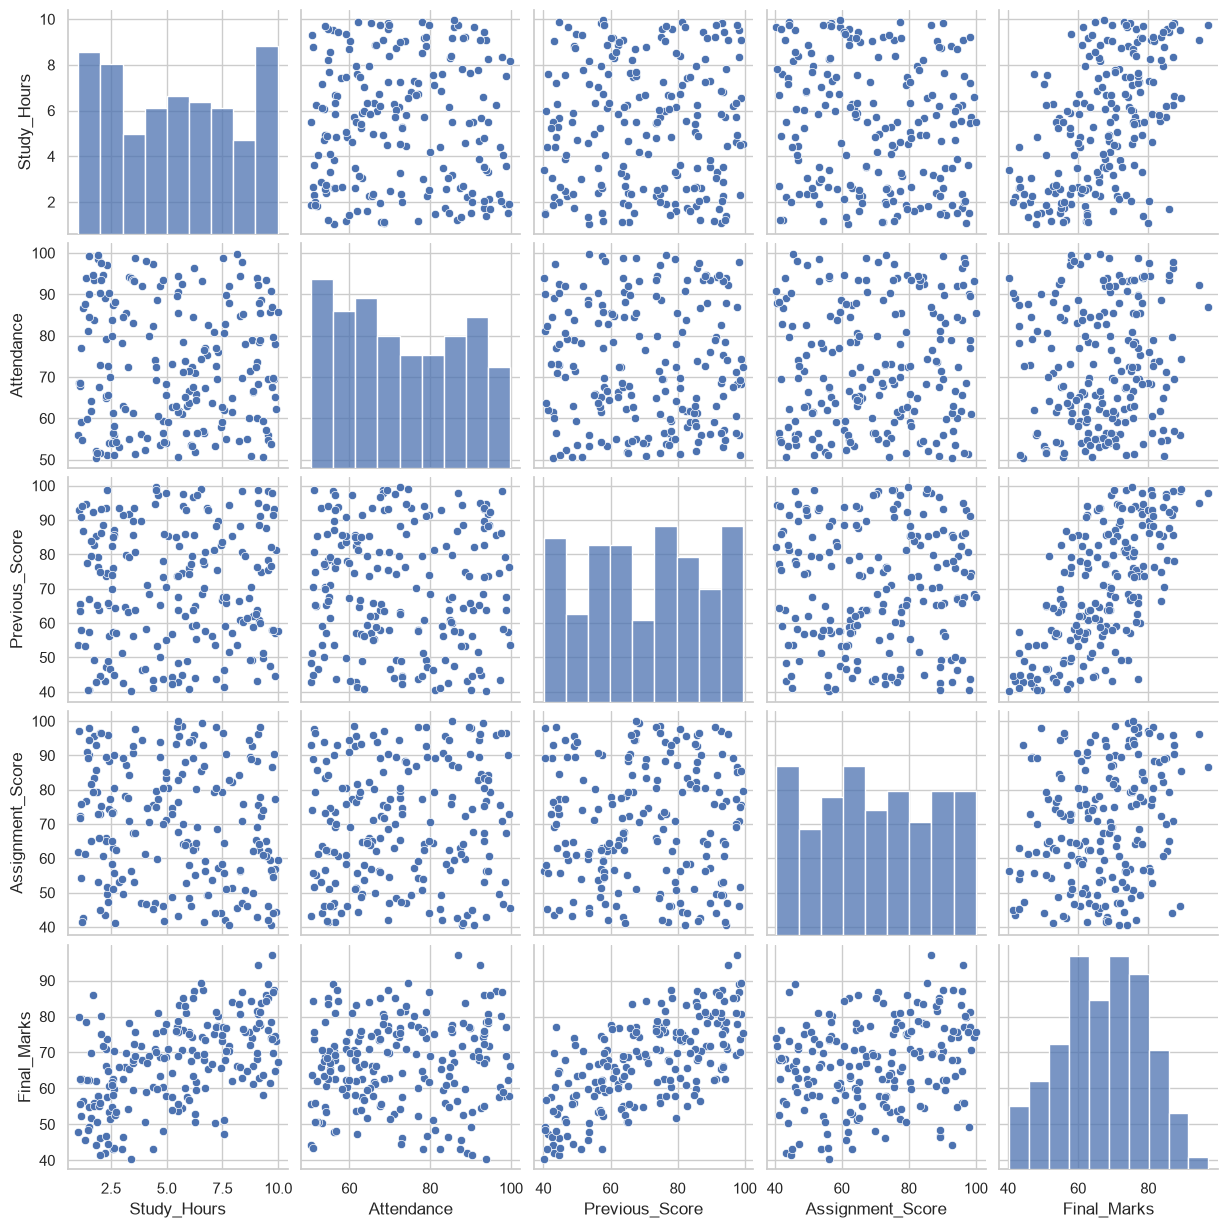

In [19]:
# Pairplot (sampled for speed)
sns.pairplot(df.sample(200), vars=['Study_Hours','Attendance','Previous_Score','Assignment_Score','Final_Marks'])
plt.show()

## Step 5: Model Building

In [20]:
# Instantiate models
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)

models = {'Linear Regression': lr, 'Decision Tree': dt, 'Random Forest': rf}

## Step 6: Model Training

In [21]:
# Train models. Use scaled features for Linear Regression and unscaled for tree models
trained_models = {}

# Linear Regression with scaled inputs
lr.fit(X_train_scaled, y_train)
trained_models['Linear Regression'] = lr

# Decision Tree and Random Forest on unscaled (X_train)
dt.fit(X_train, y_train)
trained_models['Decision Tree'] = dt

rf.fit(X_train, y_train)
trained_models['Random Forest'] = rf

print('Training completed for models:', list(trained_models.keys()))

Training completed for models: ['Linear Regression', 'Decision Tree', 'Random Forest']


## Step 7: Prediction

In [22]:
# Predictions for each model
predictions = {}

# Linear Regression (scaled features)
predictions['Linear Regression'] = lr.predict(X_test_scaled)

# Decision Tree and Random Forest (unscaled)
predictions['Decision Tree'] = dt.predict(X_test)
predictions['Random Forest'] = rf.predict(X_test)

# Create comparison DataFrame for Random Forest as example
comp_df = pd.DataFrame({
    'Actual': y_test.values,
    'LR_Pred': predictions['Linear Regression'],
    'DT_Pred': predictions['Decision Tree'],
    'RF_Pred': predictions['Random Forest']
})
comp_df.head(10)

,Actual,LR_Pred,DT_Pred,RF_Pred
0,51.09,59.692010,62.97,59.1422
1,79.86,78.457349,80.30,81.2455
2,79.66,74.993167,68.57,73.0367
3,69.15,65.256780,65.35,64.9867
4,64.23,62.224016,64.45,61.9225
5,71.96,72.065738,73.25,70.5759
6,57.20,49.744192,48.73,48.5812
7,84.32,78.752192,72.18,80.3420
8,61.68,58.009399,61.81,59.0357
9,54.50,60.221950,65.22,61.4801


## Step 8: Model Evaluation

In [23]:
# Evaluation metrics
results = []
for name, preds in predictions.items():
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': round(mae,3), 'MSE': round(mse,3), 'RMSE': round(rmse,3), 'R2': round(r2,3)})

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,3.663,21.549,4.642,0.851
2,Random Forest,4.353,29.235,5.407,0.798
1,Decision Tree,5.903,53.753,7.332,0.629


Identify best model based on RMSE and R2.

## Step 9: Visualization of Actual vs Predicted

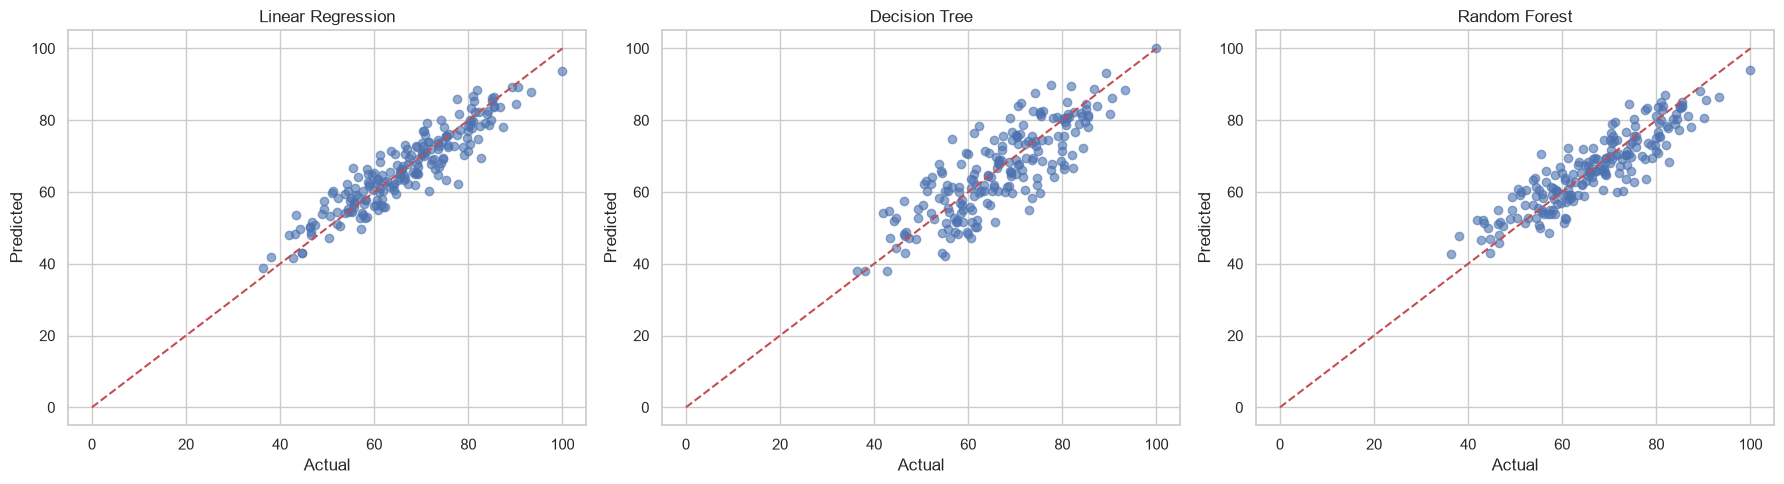

In [24]:
# Plot for each model
plt.figure(figsize=(18,5))
for i, (name, preds) in enumerate(predictions.items(), 1):
    plt.subplot(1,3,i)
    plt.scatter(y_test, preds, alpha=0.6)
    plt.plot([0,100],[0,100], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(name)
plt.tight_layout()
plt.show()

## Step 10: Feature Importance (Random Forest)

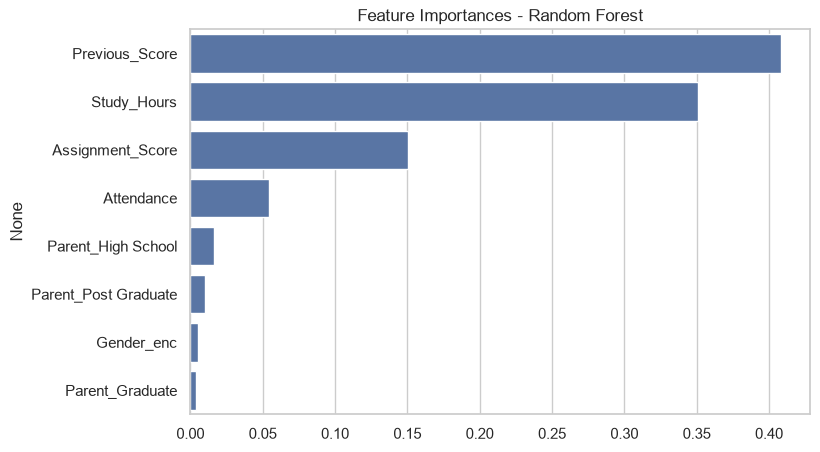

In [25]:
feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_importances = feat_importances.sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=feat_importances.values, y=feat_importances.index)
plt.title('Feature Importances - Random Forest')
plt.show()

## Step 11: User Prediction (Interactive)

In [27]:
# Choose best model based on results_df
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name] if best_model_name in trained_models else rf
print('Best model:', best_model_name)

# Example user input (replace with interactive inputs in real use)
sample = {
    'Study_Hours': 6.5,
    'Attendance': 85.0,
    'Previous_Score': 72.0,
    'Assignment_Score': 78.0,
    'Gender_enc': le.transform(['Female'])[0],
    'Parent_High School': 0,
    'Parent_Graduate': 1,
    'Parent_Post Graduate': 0
}
sample_df = pd.DataFrame([sample])

# Ensure the sample has exactly the same feature columns and ordering as training
for col in X_train.columns:
    if col not in sample_df.columns:
        sample_df[col] = 0
sample_df = sample_df[X_train.columns]

# Apply scaling to numeric columns if using linear regression
if best_model_name == 'Linear Regression':
    sample_df[numeric_cols] = scaler.transform(sample_df[numeric_cols])

pred = best_model.predict(sample_df)
print('Predicted Final Marks:', round(pred[0],2))

Best model: Linear Regression
Predicted Final Marks: 75.43


## Step 12: Save Model

In [28]:
# Save the best model to disk
model_filename = 'student_performance_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_model, f)
print('Saved model to', model_filename)

Saved model to student_performance_model.pkl


## Step 13: Load Model and Predict

In [29]:
# Load model and predict for the same sample
with open(model_filename, 'rb') as f:
    loaded_model = pickle.load(f)

pred_loaded = loaded_model.predict(sample_df)
print('Prediction from loaded model:', round(pred_loaded[0],2))

Prediction from loaded model: 75.43


## Step 14: Conclusion

- The best model is chosen based on RMSE and R² from the evaluation table.
- Study hours, previous score, assignment score, and attendance are typically the most important predictors.
- Educational institutions can use this model to identify students who may need additional support and intervene early.

## Step 15: Future Scope

- Add classification (Pass/Fail), build a Streamlit dashboard, or deploy via Flask/AWS.
- Experiment with XGBoost, deep learning models, and model explainability (SHAP/LIME).